In [11]:
import os
import sys
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
from scipy.ndimage import gaussian_filter
import colormaps as cmaps
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import seaborn as sns
from typing import List, Dict, Tuple, Optional

In [12]:
# Set plotting style
# sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.5, rc={"lines.linewidth": 2.5})
# sns.set_context("talk")

## Configuration: Data Sources and Parameters

In [41]:
# Data directory and source list
in_dir = "/pscratch/sd/w/wcmca1/hackathon/etc_data/stats/"

fig_dir = "/global/cfs/cdirs/m1867/zfeng/hk25/figures_etc_composites/spatial_mean_stats/"

# List of data sources to compare
sources = ["era5", "scream", "icon_d3hp003", "um_glm_n2560_RAL3p3", "nicam_gl11"]

# Color scheme for sources (ERA5 will be black in lifecycle plots)
source_colors = {
    'era5': 'darkgray',
    'scream': 'dodgerblue',
    'icon_d3hp003': 'deeppink',
    'um_glm_n2560_RAL3p3': 'lime',
    'nicam_gl11': 'green'
}

# Display names for sources (for plot labels)
source_display_names = {
    'era5': 'ERA5',
    'scream': 'SCREAM',
    'icon_d3hp003': 'ICON',
    'um_glm_n2560_RAL3p3': 'UM',
    'nicam_gl11': 'NICAM'
}

# ETC type labels and colors
overlap_labels = {
    0: 'Isolated',
    1: 'ETC+MCS',
    2: 'ETC+AR',
    3: 'ETC+AR+MCS'
}

etc_colors = {
    'Isolated': 'springgreen',
    'ETC+AR': 'darkorange',
    'ETC+MCS': 'dodgerblue',
    'ETC+AR+MCS': 'darkorchid'
}

# Parameters
nh_threshold = 20.0  # Latitude threshold for NH
time_resolution = 6  # hours per time step
n_steps = 15  # Number of interpolation steps for lifecycle composites

# ERA5 time filter
era5_time_start = "2019-08-01"
era5_time_end = "2020-09-01"

print(f"Data directory: {in_dir}")
print(f"Sources to load: {sources}")
print(f"NH threshold: {nh_threshold}° latitude")
print(f"Time resolution: {time_resolution} hours")
print(f"Lifecycle interpolation steps: {n_steps}")

Data directory: /pscratch/sd/w/wcmca1/hackathon/etc_data/stats/
Sources to load: ['era5', 'scream', 'icon_d3hp003', 'um_glm_n2560_RAL3p3', 'nicam_gl11']
NH threshold: 20.0° latitude
Time resolution: 6 hours
Lifecycle interpolation steps: 15


## Data Loading: Multi-Source Strategy

**Recommended Approach**: Load each source into a DataFrame with a 'source' column, then concatenate all sources into a single master DataFrame.

**Advantages**:
- Easy filtering: `df[df['source'] == 'era5']`
- Seaborn compatibility: Use `hue='source'` directly in plots
- Simple groupby operations: `df.groupby(['source', 'storm_id'])`
- Flexible statistical comparisons across sources

In [14]:
def load_source_data(source: str, in_dir: str) -> pd.DataFrame:
    """
    Load ETC spatial statistics for a single data source.
    
    Parameters:
    -----------
    source : str
        Data source name (e.g., 'era5', 'scream')
    in_dir : str
        Directory containing the netCDF files
    
    Returns:
    --------
    pd.DataFrame : DataFrame with all time points and a 'source' column
    """
    in_file = f"{in_dir}/etc_spatial_stats_{source}.nc"
    
    if not os.path.exists(in_file):
        print(f"WARNING: {in_file} does not exist. Skipping {source}.")
        return None
    
    print(f"Loading {source}...")
    ds = xr.open_dataset(in_file)
    
    # Apply time filter for ERA5
    if source == "era5":
        ds = ds.sortby('time')
        ds = ds.sel(time=slice(era5_time_start, era5_time_end))
        print(f"  Filtered ERA5 to {era5_time_start} - {era5_time_end}")
        print(f"  Time points: {len(ds.time)}")
    
    # Convert to DataFrame
    df = ds.to_dataframe().reset_index()
    
    # Add source column
    df['source'] = source
    
    print(f"  Loaded {len(df)} time points, {df['storm_id'].nunique()} unique tracks")
    
    return df


# Load all sources
print("="*60)
print("Loading data from all sources...")
print("="*60)

dfs_list = []
for source in sources:
    df_source = load_source_data(source, in_dir)
    if df_source is not None:
        dfs_list.append(df_source)

# Concatenate all sources into master DataFrame
df_all = pd.concat(dfs_list, ignore_index=True)

print("\n" + "="*60)
print("Multi-Source DataFrame Summary")
print("="*60)
print(f"Total rows: {len(df_all)}")
print(f"Sources loaded: {df_all['source'].unique()}")
print(f"\nTracks per source:")
print(df_all.groupby('source')['storm_id'].nunique())
print(f"\nColumns: {list(df_all.columns)}")

df_all.head()

Loading data from all sources...
Loading era5...
  Filtered ERA5 to 2019-08-01 - 2020-09-01
  Time points: 19073
  Loaded 19073 time points, 1380 unique tracks
Loading scream...
  Loaded 16162 time points, 1289 unique tracks
Loading icon_d3hp003...
  Loaded 16277 time points, 1262 unique tracks
Loading um_glm_n2560_RAL3p3...
  Loaded 17379 time points, 1288 unique tracks
Loading nicam_gl11...
  Loaded 19073 time points, 1380 unique tracks
Loading scream...
  Loaded 16162 time points, 1289 unique tracks
Loading icon_d3hp003...
  Loaded 16277 time points, 1262 unique tracks
Loading um_glm_n2560_RAL3p3...
  Loaded 17379 time points, 1288 unique tracks
Loading nicam_gl11...
  Loaded 16353 time points, 1194 unique tracks

Multi-Source DataFrame Summary
Total rows: 85244
Sources loaded: ['era5' 'scream' 'icon_d3hp003' 'um_glm_n2560_RAL3p3' 'nicam_gl11']

Tracks per source:
source
era5                   1380
icon_d3hp003           1262
nicam_gl11             1194
scream                 1289
u

,time,d2m_mean,d2m_min,d2m_max,hur_500hPa_mean,hur_500hPa_min,hur_500hPa_max,hur_850hPa_mean,hur_850hPa_min,hur_850hPa_max,...,va500_max,va850_mean,va850_min,va850_max,vas_mean,vas_min,vas_max,vivt_mean,vivt_min,vivt_max
0,2019-08-01,285.484680,280.608215,289.515900,61.515575,10.211954,104.923752,95.698959,76.670448,102.067421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-08-01,287.285278,283.598572,291.651367,76.899628,60.458992,101.039818,92.797981,68.810944,100.845665,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-08-01,286.718292,284.876312,288.383026,60.328335,20.579947,93.047226,89.416664,64.586678,102.223358,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-08-01,289.971130,286.656586,291.575562,69.215744,3.279198,100.577461,92.025703,76.946915,103.154404,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-08-01,287.135559,282.705688,290.299927,66.116127,11.997133,101.940453,90.721115,59.422054,101.192833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Compute Track-Level Statistics for All Sources

Compute lifetime representative statistics (min, mean, max) for each track across all sources.

In [15]:
def compute_track_statistics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute track-level lifetime statistics.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with time-series data (must have 'source' and 'storm_id' columns)
    
    Returns:
    --------
    pd.DataFrame : Track statistics with one row per track
    """
    # Group by source and storm_id
    track_stats = df.groupby(['source', 'storm_id']).agg({
        'psl_min': ['min', 'mean', 'max'],
        'pr_mean': ['min', 'mean', 'max'],
        'hus_850hPa_mean': ['min', 'mean', 'max'],
        'omega_850hPa_min': ['min', 'mean', 'max'],
        'omega_500hPa_min': ['min', 'mean', 'max'],
        'cof_lat': 'mean',
        'cof_lon': 'mean',
        'overlap_flag': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
    }).reset_index()
    
    # Flatten multi-level columns
    track_stats.columns = ['_'.join(col).strip('_') if col[1] else col[0] 
                            for col in track_stats.columns.values]
    
    # Compute track duration (count time points per track)
    duration = df.groupby(['source', 'storm_id']).size().reset_index(name='duration')
    duration['duration'] = duration['duration'] * time_resolution  # Convert to hours
    
    # Merge duration with track_stats
    track_stats = track_stats.merge(duration, on=['source', 'storm_id'])
    
    # Rename columns for clarity
    rename_dict = {
        'psl_min_min': 'psl_lifetime_min',
        'psl_min_mean': 'psl_lifetime_mean',
        'psl_min_max': 'psl_lifetime_max',
        'pr_mean_max': 'pr_lifetime_max',
        'hus_850hPa_mean_max': 'hus_850hPa_lifetime_max',
        'omega_850hPa_min_min': 'omega_850hPa_lifetime_min',
        'omega_500hPa_min_min': 'omega_500hPa_lifetime_min',
        'cof_lat_mean': 'track_mean_lat',
        'cof_lon_mean': 'track_mean_lon',
        'overlap_flag_<lambda>': 'dominant_overlap_flag'
    }
    track_stats.rename(columns=rename_dict, inplace=True)
    
    # Convert pressure from Pa to hPa
    track_stats['psl_lifetime_min_hpa'] = track_stats['psl_lifetime_min'] / 100
    
    # Map overlap flag to type name
    track_stats['overlap_type'] = track_stats['dominant_overlap_flag'].map(overlap_labels)
    
    # Map source to display name
    track_stats['source_display'] = track_stats['source'].map(source_display_names)
    
    return track_stats


# Compute statistics for all sources
print("Computing track statistics for all sources...")
track_stats_all = compute_track_statistics(df_all)

print(f"\nTrack statistics shape: {track_stats_all.shape}")
print(f"Columns: {list(track_stats_all.columns)}")
print(f"\nTracks per source:")
print(track_stats_all.groupby('source').size())

track_stats_all.head()

Computing track statistics for all sources...

Track statistics shape: (6413, 24)
Columns: ['source', 'storm_id', 'psl_lifetime_min', 'psl_lifetime_mean', 'psl_lifetime_max', 'pr_mean_min', 'pr_mean_mean', 'pr_lifetime_max', 'hus_850hPa_mean_min', 'hus_850hPa_mean_mean', 'hus_850hPa_lifetime_max', 'omega_850hPa_lifetime_min', 'omega_850hPa_min_mean', 'omega_850hPa_min_max', 'omega_500hPa_lifetime_min', 'omega_500hPa_min_mean', 'omega_500hPa_min_max', 'track_mean_lat', 'track_mean_lon', 'dominant_overlap_flag', 'duration', 'psl_lifetime_min_hpa', 'overlap_type', 'source_display']

Tracks per source:
source
era5                   1380
icon_d3hp003           1262
nicam_gl11             1194
scream                 1289
um_glm_n2560_RAL3p3    1288
dtype: int64

Track statistics shape: (6413, 24)
Columns: ['source', 'storm_id', 'psl_lifetime_min', 'psl_lifetime_mean', 'psl_lifetime_max', 'pr_mean_min', 'pr_mean_mean', 'pr_lifetime_max', 'hus_850hPa_mean_min', 'hus_850hPa_mean_mean', 'hus_850

,source,storm_id,psl_lifetime_min,psl_lifetime_mean,psl_lifetime_max,pr_mean_min,pr_mean_mean,pr_lifetime_max,hus_850hPa_mean_min,hus_850hPa_mean_mean,...,omega_500hPa_lifetime_min,omega_500hPa_min_mean,omega_500hPa_min_max,track_mean_lat,track_mean_lon,dominant_overlap_flag,duration,psl_lifetime_min_hpa,overlap_type,source_display
0,era5,1,97729.437500,98333.179688,99164.234375,0.008866,0.394850,1.655703,4.574498,6.615197,...,-3.362909,-1.212489,-0.137572,62.491071,55.991071,0.0,168,977.294373,Isolated,ERA5
1,era5,2,99878.328125,100278.320312,100623.156250,0.009223,0.226123,0.661609,7.416769,9.457612,...,-1.433023,-0.719346,-0.184929,51.000000,144.159091,0.0,66,998.783264,Isolated,ERA5
2,era5,3,99500.234375,99865.859375,100266.820312,0.025590,0.185129,0.530062,5.027950,6.020890,...,-2.819178,-0.995226,-0.248902,54.821429,305.571429,0.0,168,995.002319,Isolated,ERA5
3,era5,4,100564.875000,100727.734375,100895.867188,0.071549,0.769428,1.864792,6.238563,7.805366,...,-4.172924,-2.273144,-1.141062,48.555556,234.527778,1.0,54,1005.648743,ETC+MCS,ERA5
4,era5,5,95736.718750,98862.304688,100826.531250,0.601479,1.409455,3.292425,3.317386,5.068743,...,-4.034409,-1.552427,-0.602879,-47.687500,267.104167,3.0,72,957.367188,ETC+AR+MCS,ERA5


## Filter for Northern Hemisphere Tracks

Filter tracks with mean latitude > 20°N for all sources.

In [16]:
# Filter for NH tracks
track_stats_nh = track_stats_all[track_stats_all['track_mean_lat'] > nh_threshold].copy()
df_nh = df_all[df_all['cof_lat'] > nh_threshold].copy()

# Add display name to df_nh for consistency
df_nh['source_display'] = df_nh['source'].map(source_display_names)

print(f"Total tracks (all sources): {len(track_stats_all)}")
print(f"NH tracks (lat > {nh_threshold}°): {len(track_stats_nh)}")
print(f"\nNH tracks by source:")
print(track_stats_nh.groupby('source').size())
print(f"\nNH tracks by source and overlap type:")
print(track_stats_nh.groupby(['source', 'overlap_type']).size().unstack(fill_value=0))

Total tracks (all sources): 6413
NH tracks (lat > 20.0°): 3093

NH tracks by source:
source
era5                   656
icon_d3hp003           616
nicam_gl11             582
scream                 632
um_glm_n2560_RAL3p3    607
dtype: int64

NH tracks by source and overlap type:
overlap_type         ETC+AR  ETC+AR+MCS  ETC+MCS  Isolated
source                                                    
era5                     22         139      155       339
icon_d3hp003              8         133      195       185
nicam_gl11               17         103      143       319
scream                    6         126      229       270
um_glm_n2560_RAL3p3      43          77       66       404


## Type 1 Plotting Function: Multi-Panel Box Plots

Flexible box plot function that accepts variable list in `[rows, columns]` format.

**Features**:
- X-axis: ETC types (Isolated, ETC+AR, ETC+MCS, ETC+AR+MCS)
- Hue: Data sources (ERA5, SCREAM, ICON, UM, NICAM)
- Flexible layout: Accepts `[[var1, var2, var3], [var4, var5, var6]]` for 2x3 grid

In [95]:
def plot_boxplots_by_etc_type(
    df: pd.DataFrame,
    variables: List[List[str]],
    var_labels: Dict[str, str],
    figsize: Tuple[int, int] = (18, 12),
    title: str = "ETC Statistics Comparison by Type and Source",
    source_colors: Dict[str, str] = None,
    etc_type_order: List[str] = None,
    showfliers: bool = False,
    whis: List[float] = [5, 95],
    box_width: float = 0.8,
    xtick_rotation: int = 30,
    panel_titles: Optional[List[List[str]]] = None,
    panel_ylabels: Optional[List[List[str]]] = None,
    hspace: float = 0.3,
    wspace: float = 0.3,
) -> plt.Figure:
    """
    Create multi-panel box plots comparing sources across ETC types.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Track statistics DataFrame with 'overlap_type' and 'source_display' columns
    variables : List[List[str]]
        2D list of variable names, e.g., [[var1, var2], [var3, var4]]
        Rows = subplot rows, Columns = subplot columns
    var_labels : Dict[str, str]
        Dictionary mapping variable names to y-axis labels
    figsize : Tuple[int, int]
        Figure size (width, height)
    title : str
        Overall figure title
    source_colors : Dict[str, str]
        Color mapping for sources (uses display names as keys)
    etc_type_order : List[str]
        Order of ETC types on x-axis
    showfliers : bool
        Whether to show outliers
    whis : List[float]
        Whisker percentiles
    box_width : float
        Width of the boxes (default: 0.8)
    xtick_rotation : int
        Rotation angle for x-axis tick labels (default: 30 degrees)
    panel_titles : Optional[List[List[str]]]
        Custom titles for each panel (same structure as variables)
        If None, no panel titles are shown
    panel_ylabels : Optional[List[List[str]]]
        Custom y-axis labels for each panel (same structure as variables)
        If None, uses var_labels dictionary
    xlabel_last_row_only : bool
    hspace : float
        Height space between subplots (default: 0.3)
    wspace : float
        Width space between subplots (default: 0.3)
    
    Returns:
    --------
    plt.Figure : Matplotlib figure object
    """
    if source_colors is None:
        # Default colors using display names
        source_colors = {source_display_names[k]: v for k, v in globals()['source_colors'].items()}
    
    if etc_type_order is None:
        # etc_type_order = ['Isolated', 'ETC+AR', 'ETC+MCS', 'ETC+AR+MCS']
        etc_type_order = ['Isolated', 'ETC+MCS', 'ETC+AR', 'ETC+AR+MCS']
    
    nrows = len(variables)
    ncols = len(variables[0]) if variables else 0
    
    # Create figure with GridSpec
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=hspace, wspace=wspace)
    
    # Mean point properties
    meanpointprops = dict(marker='o', markeredgecolor='black', markeredgewidth=1,
                          markerfacecolor='white', markersize=6, zorder=3)
    
    for i, var_row in enumerate(variables):
        for j, var in enumerate(var_row):
            ax = fig.add_subplot(gs[i, j])
            
            if var not in df.columns:
                ax.text(0.5, 0.5, f'Variable\n"{var}"\nnot found', 
                       ha='center', va='center', fontsize=12, color='red')
                ax.set_xticks([])
                ax.set_yticks([])
                continue
            
            # Create box plot
            sns.boxplot(
                data=df, 
                x='overlap_type', 
                y=var,
                hue='source_display',
                order=etc_type_order,
                palette=source_colors,
                showfliers=showfliers,
                whis=whis,
                width=box_width,
                showmeans=True,
                meanprops=meanpointprops,
                ax=ax
            )
            
            # Formatting
            ax.set_xlabel('', fontweight='bold')
            
            # Set y-axis label: use panel_ylabels if provided, otherwise use var_labels
            if panel_ylabels is not None and i < len(panel_ylabels) and j < len(panel_ylabels[i]):
                ylabel = panel_ylabels[i][j]
            else:
                ylabel = var_labels.get(var, var)
            ax.set_ylabel(ylabel, fontweight='bold')

            # Set panel title if provided
            if panel_titles is not None and i < len(panel_titles) and j < len(panel_titles[i]):
                ax.set_title(panel_titles[i][j], fontweight='bold', loc='left')
            
            ax.grid(True, alpha=0.8, ls='--', axis='y')
            
            # Move legend to the right side for the last column
            if j == ncols - 1:
                ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
            else:
                ax.get_legend().remove()
            
            # Rotate x-axis labels if needed
            ax.tick_params(axis='x', rotation=xtick_rotation)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment('right')
    
    fig.suptitle(title, fontweight='bold', y=0.995)
    
    return fig


# Define variable labels for Type 1 plots
type1_var_labels = {
    'duration': 'Track Duration (hours)',
    'psl_lifetime_min_hpa': 'Lifetime-Min SLP (hPa)',
    'pr_lifetime_max': 'Lifetime-Max Precip (mm/h)',
    'hus_850hPa_lifetime_max': 'Lifetime-Max 850hPa Humidity (kg/kg)',
    'omega_850hPa_lifetime_min': 'Lifetime-Min 850hPa Omega (Pa/s)',
    'omega_500hPa_lifetime_min': 'Lifetime-Min 500hPa Omega (Pa/s)'
}

print("Type 1 plotting function created.")
print("\nExample usage:")
print("variables = [")
print("    ['duration', 'psl_lifetime_min_hpa', 'pr_lifetime_max'],")
print("    ['hus_850hPa_lifetime_max', 'omega_850hPa_lifetime_min', 'omega_500hPa_lifetime_min']")
print("]")
print("fig = plot_boxplots_by_etc_type(track_stats_nh, variables, type1_var_labels)")
print("\nWith custom panel titles and y-labels:")
print("panel_titles = [")
print("    ['(a) Duration', '(b) Pressure', '(c) Precipitation'],")
print("    ['(d) Humidity', '(e) Omega 850', '(f) Omega 500']")
print("]")
print("panel_ylabels = [")
print("    ['Hours', 'hPa', 'mm/h'],")
print("    ['kg/kg', 'Pa/s', 'Pa/s']")
print("]")
print("fig = plot_boxplots_by_etc_type(track_stats_nh, variables, type1_var_labels,")
print("                                 panel_titles=panel_titles, panel_ylabels=panel_ylabels)")

Type 1 plotting function created.

Example usage:
variables = [
    ['duration', 'psl_lifetime_min_hpa', 'pr_lifetime_max'],
    ['hus_850hPa_lifetime_max', 'omega_850hPa_lifetime_min', 'omega_500hPa_lifetime_min']
]
fig = plot_boxplots_by_etc_type(track_stats_nh, variables, type1_var_labels)

With custom panel titles and y-labels:
panel_titles = [
    ['(a) Duration', '(b) Pressure', '(c) Precipitation'],
    ['(d) Humidity', '(e) Omega 850', '(f) Omega 500']
]
panel_ylabels = [
    ['Hours', 'hPa', 'mm/h'],
    ['kg/kg', 'Pa/s', 'Pa/s']
]
fig = plot_boxplots_by_etc_type(track_stats_nh, variables, type1_var_labels,
                                 panel_titles=panel_titles, panel_ylabels=panel_ylabels)


## Type 2 Plotting Function: Multi-Panel Lifecycle Evolution

Flexible lifecycle composite plot function.

**Features**:
- ERA5: Thick black line with IQR fill
- Other sources: Colored lines (no fill)
- Separate panel for each ETC type
- Flexible layout: Accepts `[[var1, var2], [var3, var4]]` for 2x2 grid

In [ ]:
def interpolate_track_to_relative_time(df: pd.DataFrame, storm_id: int, 
                                       variable: str, n_steps: int = 15) -> pd.Series:
    """
    Interpolate a single track to normalized relative time.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Full dataframe
    storm_id : int
        Storm ID to interpolate
    variable : str
        Variable name to interpolate
    n_steps : int
        Number of interpolation steps
    
    Returns:
    --------
    pd.Series : Interpolated values at relative time steps
    """
    track_data = df[df['storm_id'] == storm_id].copy()
    
    if 'time' in track_data.columns:
        track_data = track_data.sort_values('time')
    
    if len(track_data) < 2:
        return pd.Series([np.nan] * n_steps)
    
    if variable not in track_data.columns:
        return pd.Series([np.nan] * n_steps)
    
    track_data = track_data.dropna(subset=[variable])
    
    if len(track_data) < 2:
        return pd.Series([np.nan] * n_steps)
    
    track_data['relative_time'] = np.linspace(0, 1, len(track_data))
    relative_grid = np.linspace(0, 1, n_steps)
    
    try:
        interpolated = np.interp(relative_grid, track_data['relative_time'], track_data[variable])
    except:
        return pd.Series([np.nan] * n_steps)
    
    return pd.Series(interpolated, index=relative_grid)


def compute_composite_evolution(df: pd.DataFrame, storm_ids: np.ndarray, 
                                variable: str, n_steps: int = 15) -> pd.DataFrame:
    """
    Compute composite evolution across multiple tracks.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Full dataframe
    storm_ids : array-like
        List of storm IDs to include
    variable : str
        Variable to composite
    n_steps : int
        Number of time steps in normalized timeline
    
    Returns:
    --------
    pd.DataFrame : Composite statistics (median, Q25, Q75)
    """
    interpolated_tracks = []
    
    for sid in storm_ids:
        interp_values = interpolate_track_to_relative_time(df, sid, variable, n_steps)
        if not interp_values.isna().all():
            interpolated_tracks.append(interp_values)
    
    if len(interpolated_tracks) == 0:
        return pd.DataFrame()
    
    interp_df = pd.DataFrame(interpolated_tracks)
    
    composite = pd.DataFrame({
        'relative_time': np.linspace(0, 1, n_steps),
        'median': interp_df.median(axis=0),
        'q25': interp_df.quantile(0.25, axis=0),
        'q75': interp_df.quantile(0.75, axis=0),
        'mean': interp_df.mean(axis=0),
        'std': interp_df.std(axis=0),
        'count': interp_df.count(axis=0)
    })
    
    return composite


def plot_lifecycle_evolution_by_etc_type(
    df: pd.DataFrame,
    track_stats: pd.DataFrame,
    variables: List[List[str]],
    var_labels: Dict[str, str],
    etc_types: List[str] = None,
    figsize: Tuple[int, int] = (20, 12),
    title: str = "ETC Lifecycle Evolution by Type and Source",
    source_colors: Dict[str, str] = None,
    n_steps: int = 15,
    ylims: Optional[List[List[Tuple[float, float]]]] = None,
    y_scaling: Optional[List[List[float]]] = None,
    panel_ylabels: Optional[List[List[str]]] = None,
    panel_titles: Optional[List[List[List[str]]]] = None,
    title_loc: str = 'center',
    xlabel_last_row_only: bool = True,
    arrow_y_loc: float = -0.28,
    hspace: float = 0.3,
    wspace: float = 0.3,
    sps_hspace: float = 0.1,
    sps_wspace: float = 0.1,
) -> plt.Figure:
    """
    Create multi-panel lifecycle evolution plots for each ETC type.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Time-series DataFrame with 'source', 'storm_id', 'overlap_flag' columns
    track_stats : pd.DataFrame
        Track statistics with 'source', 'storm_id', 'dominant_overlap_flag' columns
    variables : List[List[str]]
        2D list of variable names for multi-panel layout
    var_labels : Dict[str, str]
        Dictionary mapping variable names to y-axis labels
    etc_types : List[str]
        List of ETC types to plot (default: all 4 types)
    figsize : Tuple[int, int]
        Figure size
    title : str
        Overall figure title
    source_colors : Dict[str, str]
        Color mapping for sources (uses source names as keys)
    n_steps : int
        Number of interpolation steps
    ylims : Optional[List[List[Tuple[float, float]]]]
        Y-axis limits for each variable (same structure as variables)
        Applied to all 4 ETC types for that variable
    y_scaling : Optional[List[List[float]]]
        Scaling factor for each variable (same structure as variables)
        E.g., 0.01 to convert Pa to hPa
    panel_ylabels : Optional[List[List[str]]]
        Custom y-axis labels (same structure as variables)
        If None, uses var_labels dictionary
    panel_titles : Optional[List[List[List[str]]]]
        Custom panel titles (3D list: [row][col][etc_type])
    title_loc : str
        Location of panel titles (default: 'center')
    xlabel_last_row_only : bool
        If True (default), only show x-axis labels on the last row when nrows > 1
        If False, show x-axis labels on all panels
    arrow_y_loc : float
        Y position for arrows in axes fraction coordinates (default: -0.28)
        Negative values position the arrow below the x-axis
    hspace : float
        Height space between subplots (default: 0.3)
    wspace : float
        Width space between subplots (default: 0.3)
    sps_hspace: float
        Height space between SubplotSpec (default: 0.1)
    sps_wspace: float
        Width space between SubplotSpec (default: 0.1)
    
    Returns:
    --------
    plt.Figure : Matplotlib figure object
    """
    # Use lifecycle-specific color scheme
    if source_colors is None:
        source_colors = {
            'era5': 'black',
            'scream': 'crimson',
            'icon_d3hp003': 'dodgerblue',
            'um_glm_n2560_RAL3p3': 'green',
            'nicam_gl11': 'darkorange'
        }
    
    if etc_types is None:
        # etc_types = ['Isolated', 'ETC+AR', 'ETC+MCS', 'ETC+AR+MCS']
        etc_types = ['Isolated', 'ETC+MCS', 'ETC+AR', 'ETC+AR+MCS']
    
    nrows = len(variables)
    ncols = len(variables[0]) * len(etc_types) if variables else 0
    
    # Create figure with nested structure: each row has (var1_ETC1, var1_ETC2, var1_ETC3, var1_ETC4, var2_ETC1, ...)
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(nrows, len(variables[0]), figure=fig, hspace=hspace, wspace=wspace, 
                          bottom=0.12)  # Increase bottom margin for arrow space
    
    for row_idx, var_row in enumerate(variables):
        for var_idx, variable in enumerate(var_row):
            # Create sub-gridspec for the 4 ETC types
            gs_sub = gridspec.GridSpecFromSubplotSpec(1, len(etc_types), 
                                                      subplot_spec=gs[row_idx, var_idx],
                                                      hspace=sps_hspace, wspace=sps_wspace)
            
            for etc_idx, etc_type in enumerate(etc_types):
                ax = fig.add_subplot(gs_sub[etc_idx])
                
                # Get overlap flag number
                overlap_flag = {v: k for k, v in overlap_labels.items()}[etc_type]
                # scaling = y_scaling[row_idx][var_idx]
                # # Get scaling factor for this variable
                # scaling = 1.0
                if y_scaling is not None and row_idx < len(y_scaling) and var_idx < len(y_scaling[row_idx]):
                    scaling = y_scaling[row_idx][var_idx]
                
                # Plot each source
                for source in df['source'].unique():
                    # Get storm IDs for this source and ETC type
                    mask = (track_stats['source'] == source) & \
                           (track_stats['dominant_overlap_flag'] == overlap_flag)
                    storm_ids = track_stats[mask]['storm_id'].values
                    
                    if len(storm_ids) < 5:  # Skip if too few tracks
                        continue
                    
                    # Filter df for this source
                    df_source = df[df['source'] == source]
                    
                    # Compute composite
                    composite = compute_composite_evolution(df_source, storm_ids, variable, n_steps)
                    
                    if composite.empty:
                        continue

                    # Apply scaling
                    composite_scaled = composite.copy()
                    for col in ['median', 'q25', 'q75', 'mean']:
                        composite_scaled[col] = composite[col] * scaling
                    
                    # Plot styling
                    color = source_colors[source]
                    default_linewidth = plt.rcParams['lines.linewidth']
                    linewidth = default_linewidth * 1.6 if source == 'era5' else default_linewidth
                    alpha = 1.0 if source == 'era5' else 1.0
                    label = source_display_names[source]
                    
                    # Plot median line
                    ax.plot(composite_scaled['relative_time'], composite_scaled['median'],
                           color=color, linewidth=linewidth, alpha=alpha, label=label)
                    
                    # Fill IQR only for ERA5
                    if source == 'era5':
                        ax.fill_between(composite_scaled['relative_time'],
                                        composite_scaled['q25'],
                                        composite_scaled['q75'],
                                        color=color, edgecolor='none', alpha=0.2)
                        
                # X-axis label: show only on last row if xlabel_last_row_only is True and nrows > 1
                if xlabel_last_row_only and nrows > 1:
                    if row_idx == nrows - 1:
                        # Last row: show x-axis labels
                        ax.set_xlabel('Relative Lifetime', fontweight='bold')
                    else:
                        # Not last row: hide x-axis labels but keep x-axis visible
                        ax.set_xlabel('')
                        # ax.set_xticklabels([])
                else:
                    # Show x-axis labels on all panels
                    ax.set_xlabel('Relative Lifetime', fontweight='bold')
                
                # Set y-axis label: only for leftmost panel of each variable column (etc_idx == 0)
                if etc_idx == 0:
                    if panel_ylabels is not None and row_idx < len(panel_ylabels) and var_idx < len(panel_ylabels[row_idx]):
                        ylabel = panel_ylabels[row_idx][var_idx]
                    else:
                        ylabel = var_labels.get(variable, variable)
                    ax.set_ylabel(ylabel, fontweight='bold')
                
                # Set panel title
                if panel_titles is not None and row_idx < len(panel_titles) and var_idx < len(panel_titles[row_idx]) and etc_idx < len(panel_titles[row_idx][var_idx]):
                    ax.set_title(panel_titles[row_idx][var_idx][etc_idx], fontweight='bold', loc=title_loc)
                else:
                    ax.set_title(f'{etc_type}', fontweight='bold', loc=title_loc)
                
                # Set y-axis limits if provided (same ylim for all 4 ETC types of the same variable)
                if ylims is not None and row_idx < len(ylims) and var_idx < len(ylims[row_idx]):
                    ax.set_ylim(ylims[row_idx][var_idx])
                
                ax.grid(True, ls='--', alpha=0.8)
                ax.set_xlim(0, 1)
                
                # Legend only on the rightmost panel of the first row
                if row_idx == 0 and var_idx == 0 and etc_idx == len(etc_types) - 1:
                    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
                
                # Add arrow underneath last row panels
                if row_idx == nrows - 1:
                    ax.annotate('', xy=(1, arrow_y_loc), xytext=(0, arrow_y_loc), xycoords='axes fraction',
                                arrowprops=dict(arrowstyle='->', lw=4, color='black'))
    
    fig.suptitle(title, fontweight='bold', y=0.98)
    
    return fig


# Define variable labels for Type 2 plots
type2_var_labels = {
    'psl_min': 'Min SLP (Pa)',
    'pr_mean': 'Mean Precip (mm/h)',
    'hus_850hPa_mean': '850hPa Humidity (kg/kg)',
    'omega_850hPa_min': '850hPa Omega (Pa/s)',
    'omega_500hPa_min': '500hPa Omega (Pa/s)'
}

print("Type 2 plotting function created.")
print("\nExample usage:")
print("variables = [['psl_min', 'pr_mean'], ['hus_850hPa_mean', 'omega_850hPa_min']]")
print("fig = plot_lifecycle_evolution_by_etc_type(df_nh, track_stats_nh, variables, type2_var_labels)")

print("\nWith custom options:")
print("    ['(e) Isolated', '(f) ETC+AR', '(g) ETC+MCS', '(h) ETC+AR+MCS']   # Row 1, Col 2")
print("    panel_ylabels=panel_ylabels, panel_titles=panel_titles)")
print("    panel_ylabels=panel_ylabels, panel_titles=panel_titles)")

print("ylims = [[(950, 1020), (0, 0.5)]]  # Same limits for all 4 ETC types per variable")
print("]]")
print("    type2_var_labels, ylims=ylims, y_scaling=y_scaling,")

print("y_scaling = [[0.01, 1.0]]  # Convert Pa to hPa for psl_min")
print("fig = plot_lifecycle_evolution_by_etc_type(df_nh, track_stats_nh, variables,")
print("fig = plot_lifecycle_evolution_by_etc_type(df_nh, track_stats_nh, variables,")

print("panel_ylabels = [['SLP (hPa)', 'Precip (mm/h)']]")
print("    type2_var_labels, ylims=ylims, y_scaling=y_scaling,")
print("]]")

print("panel_titles = [[")
print("    panel_ylabels=panel_ylabels, panel_titles=panel_titles)")
print("    ['(e) Isolated', '(f) ETC+AR', '(g) ETC+MCS', '(h) ETC+AR+MCS']   # Row 1, Col 2")
print("    ['(a) Isolated', '(b) ETC+AR', '(c) ETC+MCS', '(d) ETC+AR+MCS'],  # Row 1, Col 1")

Type 2 plotting function created.

Example usage:
variables = [['psl_min', 'pr_mean'], ['hus_850hPa_mean', 'omega_850hPa_min']]
fig = plot_lifecycle_evolution_by_etc_type(df_nh, track_stats_nh, variables, type2_var_labels)

With custom options:
    ['(e) Isolated', '(f) ETC+AR', '(g) ETC+MCS', '(h) ETC+AR+MCS']   # Row 1, Col 2
    panel_ylabels=panel_ylabels, panel_titles=panel_titles)
    panel_ylabels=panel_ylabels, panel_titles=panel_titles)
ylims = [[(950, 1020), (0, 0.5)]]  # Same limits for all 4 ETC types per variable
]]
    type2_var_labels, ylims=ylims, y_scaling=y_scaling,
y_scaling = [[0.01, 1.0]]  # Convert Pa to hPa for psl_min
fig = plot_lifecycle_evolution_by_etc_type(df_nh, track_stats_nh, variables,
fig = plot_lifecycle_evolution_by_etc_type(df_nh, track_stats_nh, variables,
panel_ylabels = [['SLP (hPa)', 'Precip (mm/h)']]
    type2_var_labels, ylims=ylims, y_scaling=y_scaling,
]]
panel_titles = [[
    panel_ylabels=panel_ylabels, panel_titles=panel_titles)
    ['(e) 

## Example: Type 1 Box Plots (2 rows × 3 columns)

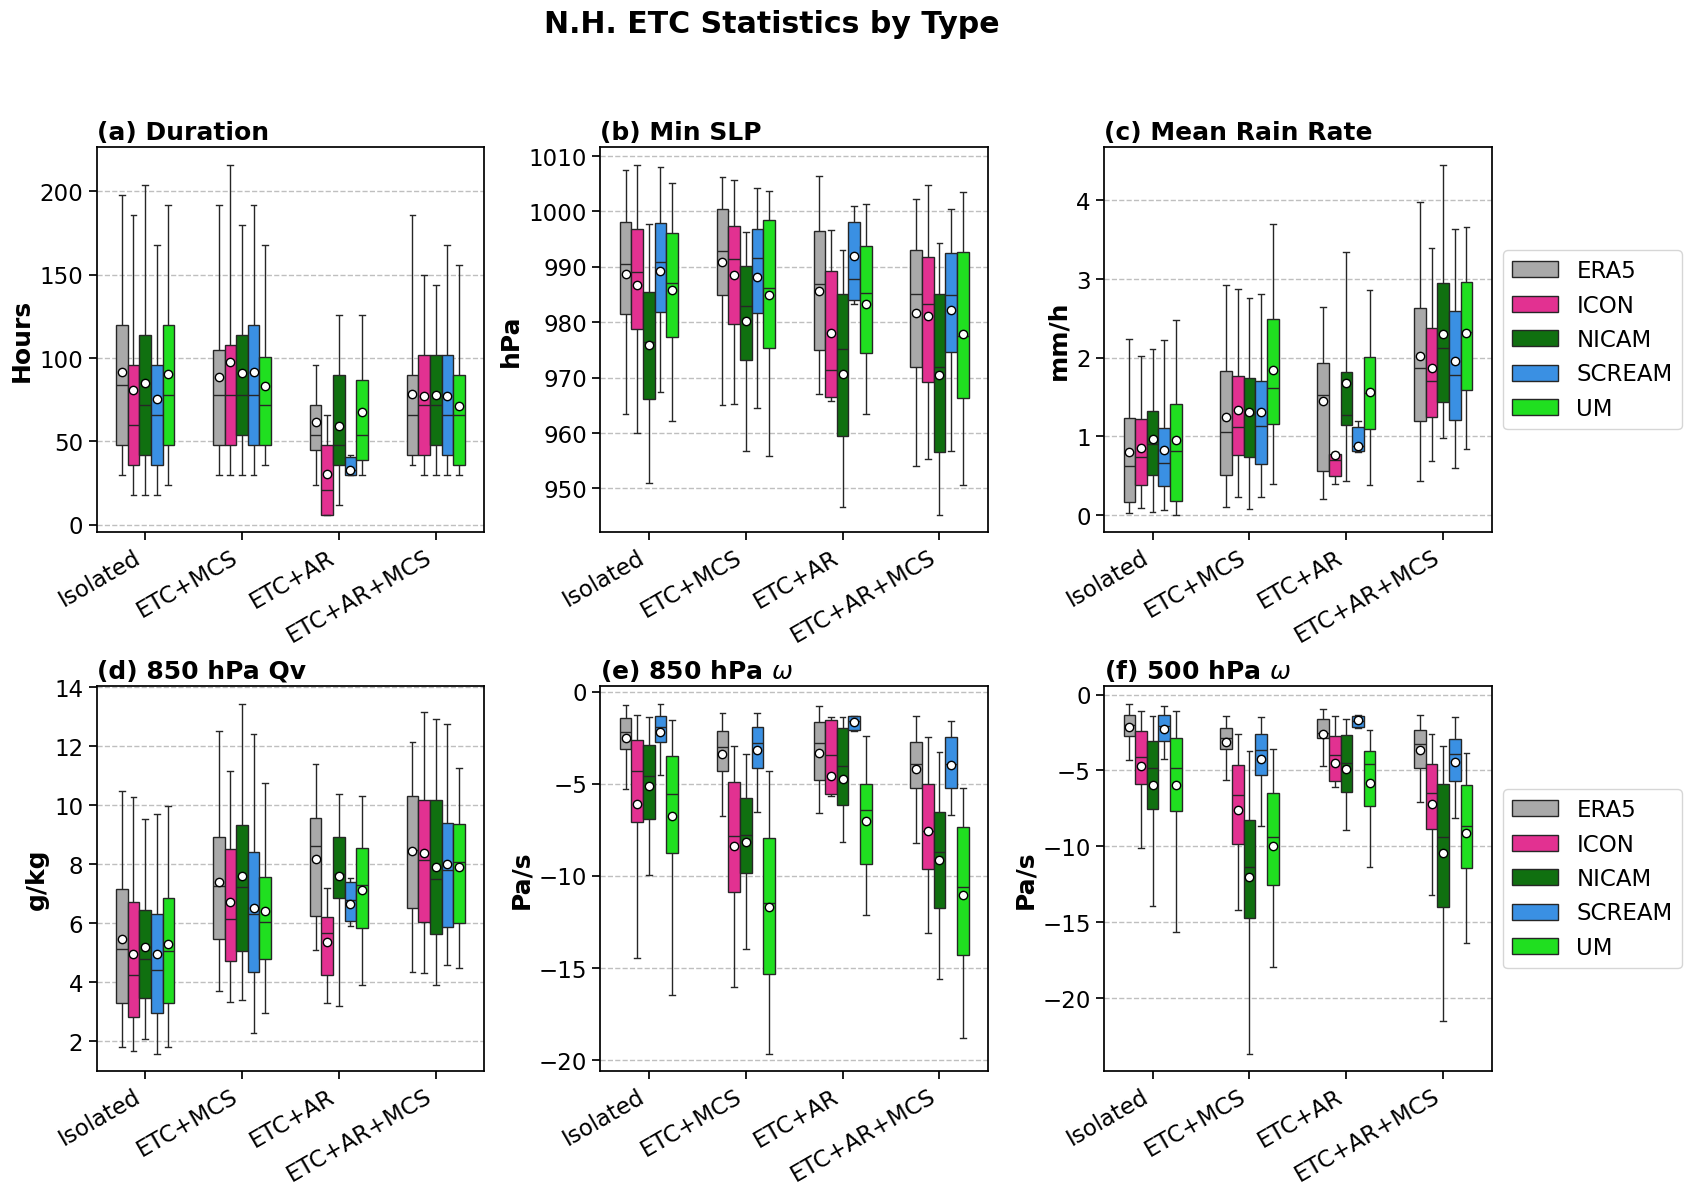

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_etc_composites/spatial_mean_stats/ETC_lifetime_boxplot_by4ETCtypes_duration_psl_pr_hus850_omega850_omega500.pdf


In [114]:
# Define variables for Type 1 plots (2 rows × 3 columns)
type1_variables = [
    ['duration', 'psl_lifetime_min_hpa', 'pr_lifetime_max'],
    ['hus_850hPa_lifetime_max', 'omega_850hPa_lifetime_min', 'omega_500hPa_lifetime_min']
]
panel_titles = [
    ['(a) Duration', '(b) Min SLP', '(c) Mean Rain Rate'],
    ['(d) 850 hPa Qv', '(e) 850 hPa $\\omega$', '(f) 500 hPa $\\omega$']
]
panel_ylabels = [
    ['Hours', 'hPa', 'mm/h'],
    ['g/kg', 'Pa/s', 'Pa/s']
]
# Create color palette for sources using display names
source_colors_display = {source_display_names[k]: v for k, v in source_colors.items()}

# Create box plots
fig = plot_boxplots_by_etc_type(
    track_stats_nh,
    type1_variables,
    type1_var_labels,
    figsize=(18, 12),
    title="N.H. ETC Statistics by Type",
    source_colors=source_colors_display,
    box_width=0.6,
    xtick_rotation=30,
    panel_titles=panel_titles,
    panel_ylabels=panel_ylabels,
    hspace=0.4, wspace=0.3,
)

plt.show()

figname = f"{fig_dir}ETC_lifetime_boxplot_by4ETCtypes_duration_psl_pr_hus850_omega850_omega500.pdf"
fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='white')

print(f"Figure saved: {figname}")

## Example: Type 2 Lifecycle Evolution (1 row × 2 columns, 4 ETC types each)

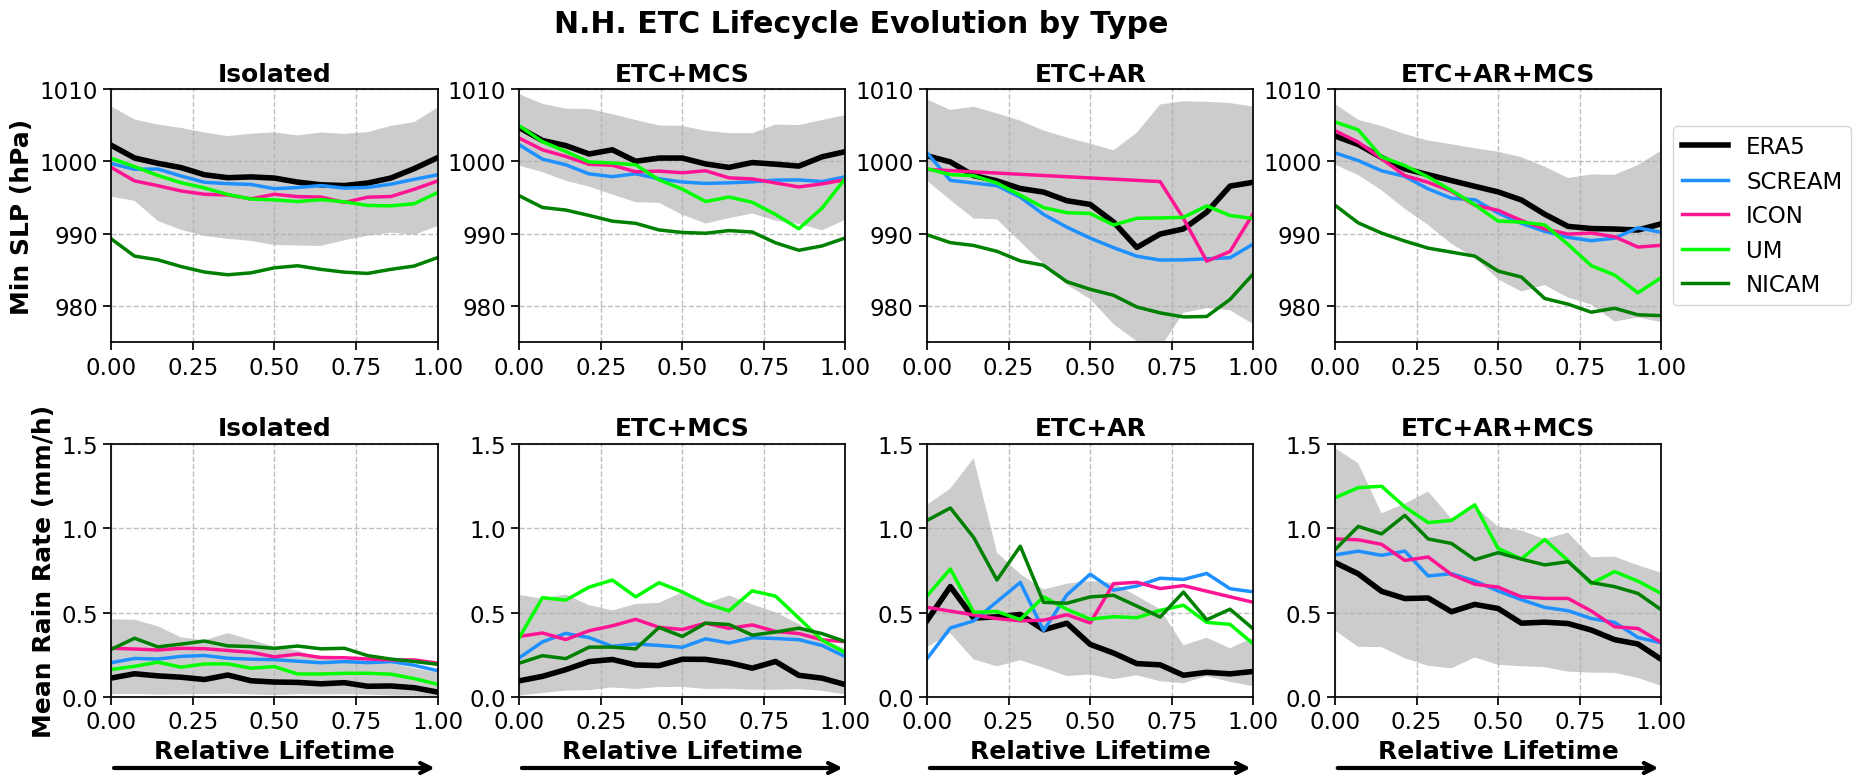

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_etc_composites/spatial_mean_stats/ETC_composite_lifecycle_by4ETCtypes_psl_pr.pdf


In [115]:
# Define variables for Type 2 plots (2 rows × 1 column each, 4 ETC panels per variable)
type2_variables = [
    ['psl_min'],   # Row 0: SLP (will create 4 panels for 4 ETC types)
    ['pr_mean'],   # Row 1: Precip (will create 4 panels for 4 ETC types)
]
# Each row has 1 variable column, so parameters are 2D lists with 1 element per row
ylims = [
    [(975, 1010)],  # Row 0 (psl_min): limits applied to all 4 ETC panels
    [(0, 1.5)]      # Row 1 (pr_mean): limits applied to all 4 ETC panels
]
y_scaling = [
    [0.01],  # Row 0 (psl_min): convert Pa to hPa
    [1.0]    # Row 1 (pr_mean): no scaling
]
panel_ylabels = [
    ['Min SLP (hPa)'],  # Row 0 ylabel (shown on leftmost panel only)
    ['Mean Rain Rate (mm/h)']      # Row 1 ylabel (shown on leftmost panel only)
]
# panel_titles = [
#     [['(a) Isolated', '(b) ETC+AR', '(c) ETC+MCS', '(d) ETC+AR+MCS']],  # Row 0: 4 titles for psl_min
#     [['(e) Isolated', '(f) ETC+AR', '(g) ETC+MCS', '(h) ETC+AR+MCS']]   # Row 1: 4 titles for pr_mean
# ]
panel_titles = None
title_loc = 'center'
# Update the source colors for ERA5
line_colors = source_colors.copy()
line_colors['era5'] = 'black'  # ERA5 in black for lifecycle plots

# Create lifecycle evolution plots
fig = plot_lifecycle_evolution_by_etc_type(
    df_nh,
    track_stats_nh,
    type2_variables,
    type2_var_labels,
    source_colors=line_colors,
    figsize=(20, 8),
    title="N.H. ETC Lifecycle Evolution by Type",
    n_steps=n_steps,
    ylims=ylims, y_scaling=y_scaling,
    panel_ylabels=panel_ylabels, panel_titles=panel_titles, title_loc=title_loc,
    hspace=0.4, wspace=0.3, sps_hspace=0.1, sps_wspace=0.25,
)

plt.show()

figname = f"{fig_dir}ETC_composite_lifecycle_by4ETCtypes_psl_pr.pdf"
fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='white')

print(f"Figure saved: {figname}")

## Example: Type 2 with All 6 Variables (2 rows × 3 columns)

In [89]:
track_stats_nh.omega_850hPa_lifetime_min.describe()

count    3092.000000
mean       -5.544393
std         4.415364
min       -66.260910
25%        -7.487426
50%        -4.293050
75%        -2.416665
max        -0.220233
Name: omega_850hPa_lifetime_min, dtype: float64

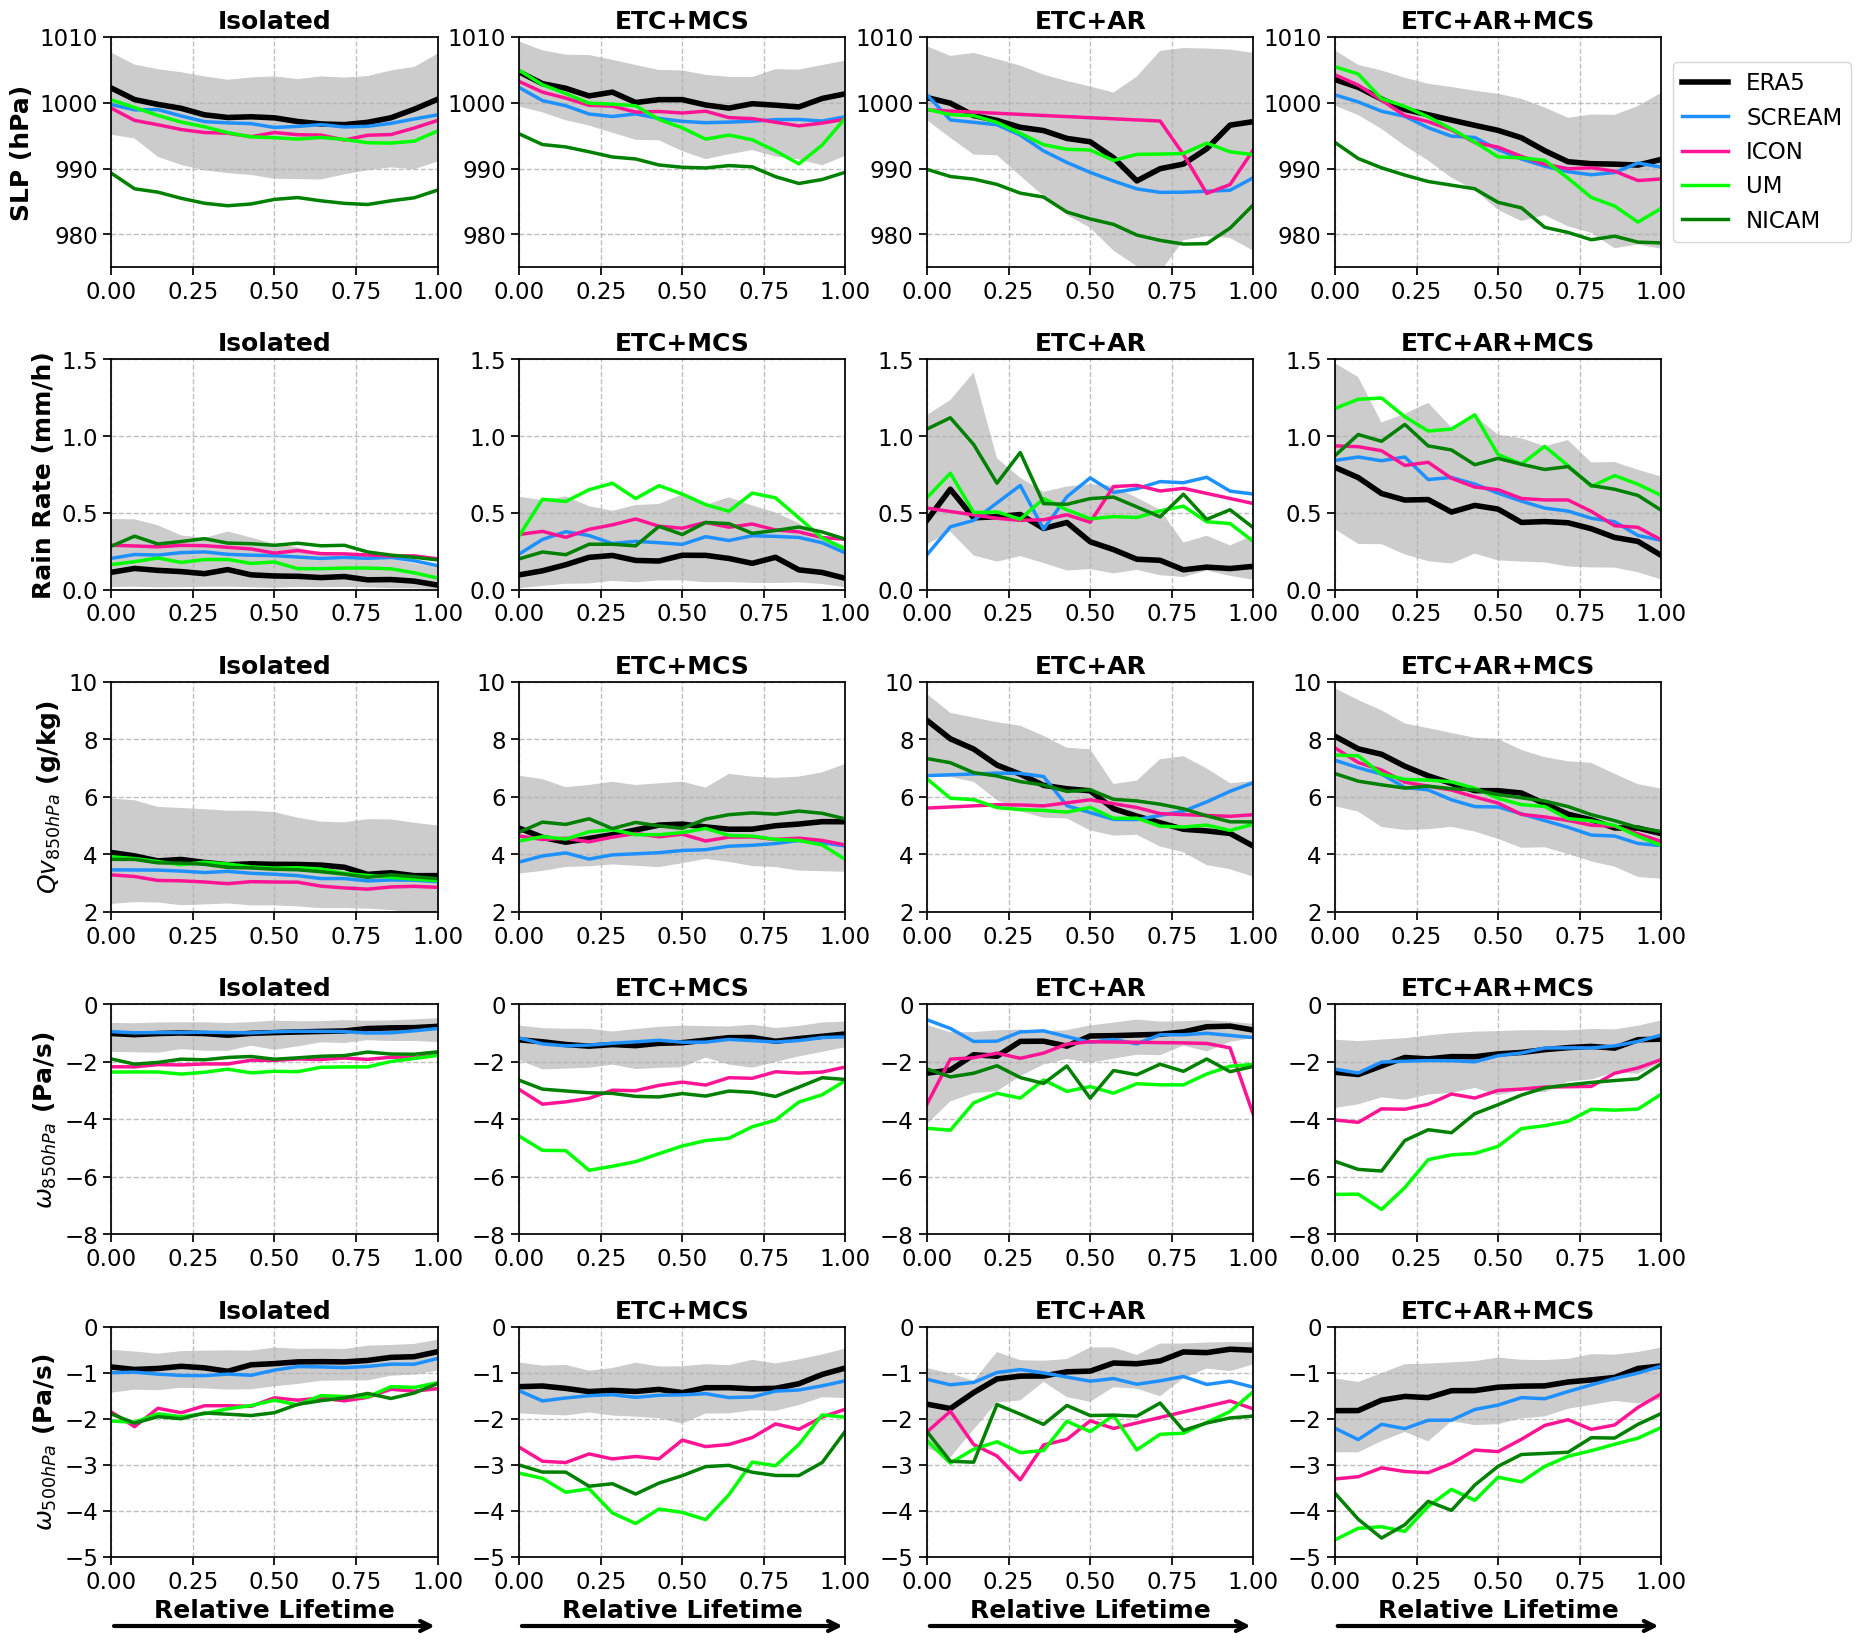

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_etc_composites/spatial_mean_stats/ETC_composite_lifecycle_by4ETCtypes_psl_pr_hus850_omega850_omega500.pdf


In [116]:
# Define all variables for comprehensive lifecycle comparison
type2_variables = [
    ['psl_min'], ['pr_mean'], ['hus_850hPa_mean'],
    ['omega_850hPa_min'], ['omega_500hPa_min'],
]

# Each row has 1 variable column, so parameters are 2D lists with 1 element per row
ylims = [
    [(975, 1010)],  # Row 0 (psl_min): limits applied to all 4 ETC panels
    [(0, 1.5)],      # Row 1 (pr_mean): limits applied to all 4 ETC panels
    [(2, 10)],    # Row 2 (hus_850hPa_mean)
    [(-8, 0)],   # Row 3 (omega_850hPa_min)
    [(-5, 0)],    # Row 4 (omega_500hPa_min)
]
y_scaling = [
    [0.01],  # Row 0 (psl_min): convert Pa to hPa
    [1.0],    # Row 1 (pr_mean): no scaling
    [1.0],    # Row 2 (hus_850hPa_mean): no scaling
    [1.0],    # Row 3 (omega_850hPa_min): no scaling
    [1.0],     # Row 4 (omega_500hPa_min): no scaling
]
panel_ylabels = [
    ["SLP (hPa)"],  # Row 0 ylabel (shown on leftmost panel only)
    ["Rain Rate (mm/h)"],      # Row 1 ylabel (shown on leftmost panel only)
    ["$Qv_{850 hPa}$ (g/kg)"],      # Row 2 ylabel
    [r"$\omega_{850 hPa}$ (Pa/s)"],       # Row 3 ylabel
    [r"$\omega_{500 hPa}$ (Pa/s)"],        # Row 4 ylabel
]
# panel_titles = [
#     [['(a) Isolated', '(b) ETC+AR', '(c) ETC+MCS', '(d) ETC+AR+MCS']],  # Row 0: 4 titles for psl_min
#     [['(e) Isolated', '(f) ETC+AR', '(g) ETC+MCS', '(h) ETC+AR+MCS']]   # Row 1: 4 titles for pr_mean
# ]
panel_titles = None
title_loc = 'center'
# Update the source colors for ERA5
line_colors = source_colors.copy()
line_colors['era5'] = 'black'  # ERA5 in black for lifecycle plots

# Create lifecycle evolution plots
fig = plot_lifecycle_evolution_by_etc_type(
    df_nh,
    track_stats_nh,
    type2_variables,
    type2_var_labels,
    source_colors=line_colors,
    figsize=(20, 20),
    title="",
    n_steps=n_steps,
    ylims=ylims, y_scaling=y_scaling,
    panel_ylabels=panel_ylabels, panel_titles=panel_titles, title_loc=title_loc,
    hspace=0.4, wspace=0.3, sps_hspace=0.1, sps_wspace=0.25,
    arrow_y_loc=-0.3,
)

plt.show()

figname = f"{fig_dir}ETC_composite_lifecycle_by4ETCtypes_psl_pr_hus850_omega850_omega500.pdf"
fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='white')

print(f"Figure saved: {figname}")

## Summary Statistics by Source and ETC Type

In [91]:
# Summary statistics table
print("="*80)
print("NH Track Count by Source and ETC Type")
print("="*80)
summary_counts = track_stats_nh.groupby(['source_display', 'overlap_type']).size().unstack(fill_value=0)
print(summary_counts)
print("\n")

print("="*80)
print("Mean Track Duration (hours) by Source and ETC Type")
print("="*80)
summary_duration = track_stats_nh.groupby(['source_display', 'overlap_type'])['duration'].mean().unstack()
print(summary_duration.round(1))
print("\n")

print("="*80)
print("Mean Lifetime-Min SLP (hPa) by Source and ETC Type")
print("="*80)
summary_psl = track_stats_nh.groupby(['source_display', 'overlap_type'])['psl_lifetime_min_hpa'].mean().unstack()
print(summary_psl.round(1))
print("\n")

print("="*80)
print("Mean Lifetime-Max Precip (mm/h) by Source and ETC Type")
print("="*80)
summary_pr = track_stats_nh.groupby(['source_display', 'overlap_type'])['pr_lifetime_max'].mean().unstack()
print(summary_pr.round(3))

NH Track Count by Source and ETC Type
overlap_type    ETC+AR  ETC+AR+MCS  ETC+MCS  Isolated
source_display                                       
ERA5                22         139      155       339
ICON                 8         133      195       185
NICAM               17         103      143       319
SCREAM               6         126      229       270
UM                  43          77       66       404


Mean Track Duration (hours) by Source and ETC Type
overlap_type    ETC+AR  ETC+AR+MCS  ETC+MCS  Isolated
source_display                                       
ERA5              61.4        78.2     88.8      91.7
ICON              30.8        77.3     97.9      80.6
NICAM             59.3        78.1     91.0      85.1
SCREAM            33.0        77.0     91.7      75.2
UM                67.8        71.4     83.3      90.6


Mean Lifetime-Min SLP (hPa) by Source and ETC Type
overlap_type        ETC+AR  ETC+AR+MCS     ETC+MCS    Isolated
source_display                       

## Data Organization Summary

### DataFrame Structure:

**`df_all` / `df_nh`** (Time-series data):
- Rows: Individual time points for all tracks across all sources
- Key columns: `source`, `storm_id`, `time`, `psl_min`, `pr_mean`, `overlap_flag`, etc.
- Usage: Lifecycle evolution analysis (interpolate each track to relative time)

**`track_stats_all` / `track_stats_nh`** (Track-level statistics):
- Rows: One row per track (aggregated over lifetime)
- Key columns: `source`, `storm_id`, `duration`, `psl_lifetime_min`, `dominant_overlap_flag`, `overlap_type`, etc.
- Usage: Box plots, statistical comparisons across sources and ETC types

### Advantages of This Approach:
1. **Easy filtering**: `df[df['source'] == 'era5']` or `df[df['overlap_type'] == 'ETC+AR']`
2. **Seaborn integration**: Use `hue='source_display'` directly
3. **Flexible groupby**: `df.groupby(['source', 'overlap_type'])['variable'].mean()`
4. **Unified analysis**: All sources in one DataFrame for consistent operations

### Plotting Functions:
- **Type 1**: `plot_boxplots_by_etc_type()` - Multi-panel box plots with flexible layout
- **Type 2**: `plot_lifecycle_evolution_by_etc_type()` - Multi-panel lifecycle evolution with ERA5 highlighting